I am going to review diffusion models and specifically the DDIM sampler.

Sources:

https://arxiv.org/pdf/2006.11239 - Denoising Diffusion Probabilistic Models

https://arxiv.org/pdf/2112.10752 - High-Resolution Image Synthesis with Latent Diffusion Models

https://arxiv.org/abs/2010.02502 - Denoising Diffusion Implicit Models

Diffusion is a technique applied to image generation tasks. GANs can be difficult to train because of mode collapse meanwhile VAEs can fail to produce accurate specific features because they focus on more general patterns. Diffusion models work by starting with a real image and adding noise in a series of steps to it meanwhile a diffusion neural network is trained to undo that step of noise. DDPM's training objective is the noise that was added to the model on the last step and it uses a loss of MSE between the true noise and the predicted noise. During inference and image generation a diffusion model iterates starting from pure noise and eventually produces a fully denoised image. In the original and in stable diffusion (https://arxiv.org/pdf/2112.10752) they specifically work by predicting what the noise added at a timestep was and then subtracting that noise according to a specific formula (seen on page 4 of Denoising Diffusion Probabilistic Models). Additionally each backwards step involves adding a little bit of noise which improves the stability. My intuition of this is that it might prevent the diffusion model from too quickly removing noise resulting in a suboptimal low-noise but poor image. By continuining to add noise it prevents quick convergence to a suboptimal result. However this causes diffusion models to require many steps to result in a good output image. DDIM (https://arxiv.org/abs/2010.02502) changes this process by predicting exactly what the output image would be and then having the model take a controlled step towards the result scaled such that earlier steps result in larger changes and later steps are smaller. This means that early steps with high amounts of noise start moving very quickly towards a refined image. Then as the number of iterations increase it starts creating smaller refinements to prevent overshooting. This can produce images 10-50 times faster than with the original DDPM.

In [15]:
!pip install -q diffusers torch torchvision accelerate

import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler
from PIL import Image
import time
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import numpy as np

from diffusers import (
    StableDiffusionPipeline,
    DDPMScheduler,
    DDIMScheduler,
    EulerDiscreteScheduler,
    DPMSolverMultistepScheduler,
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

   DPM++ |  10 steps →  0.76s


  0%|          | 0/30 [00:00<?, ?it/s]

   DPM++ |  30 steps →  2.08s


  0%|          | 0/60 [00:00<?, ?it/s]

   DPM++ |  60 steps →  4.08s


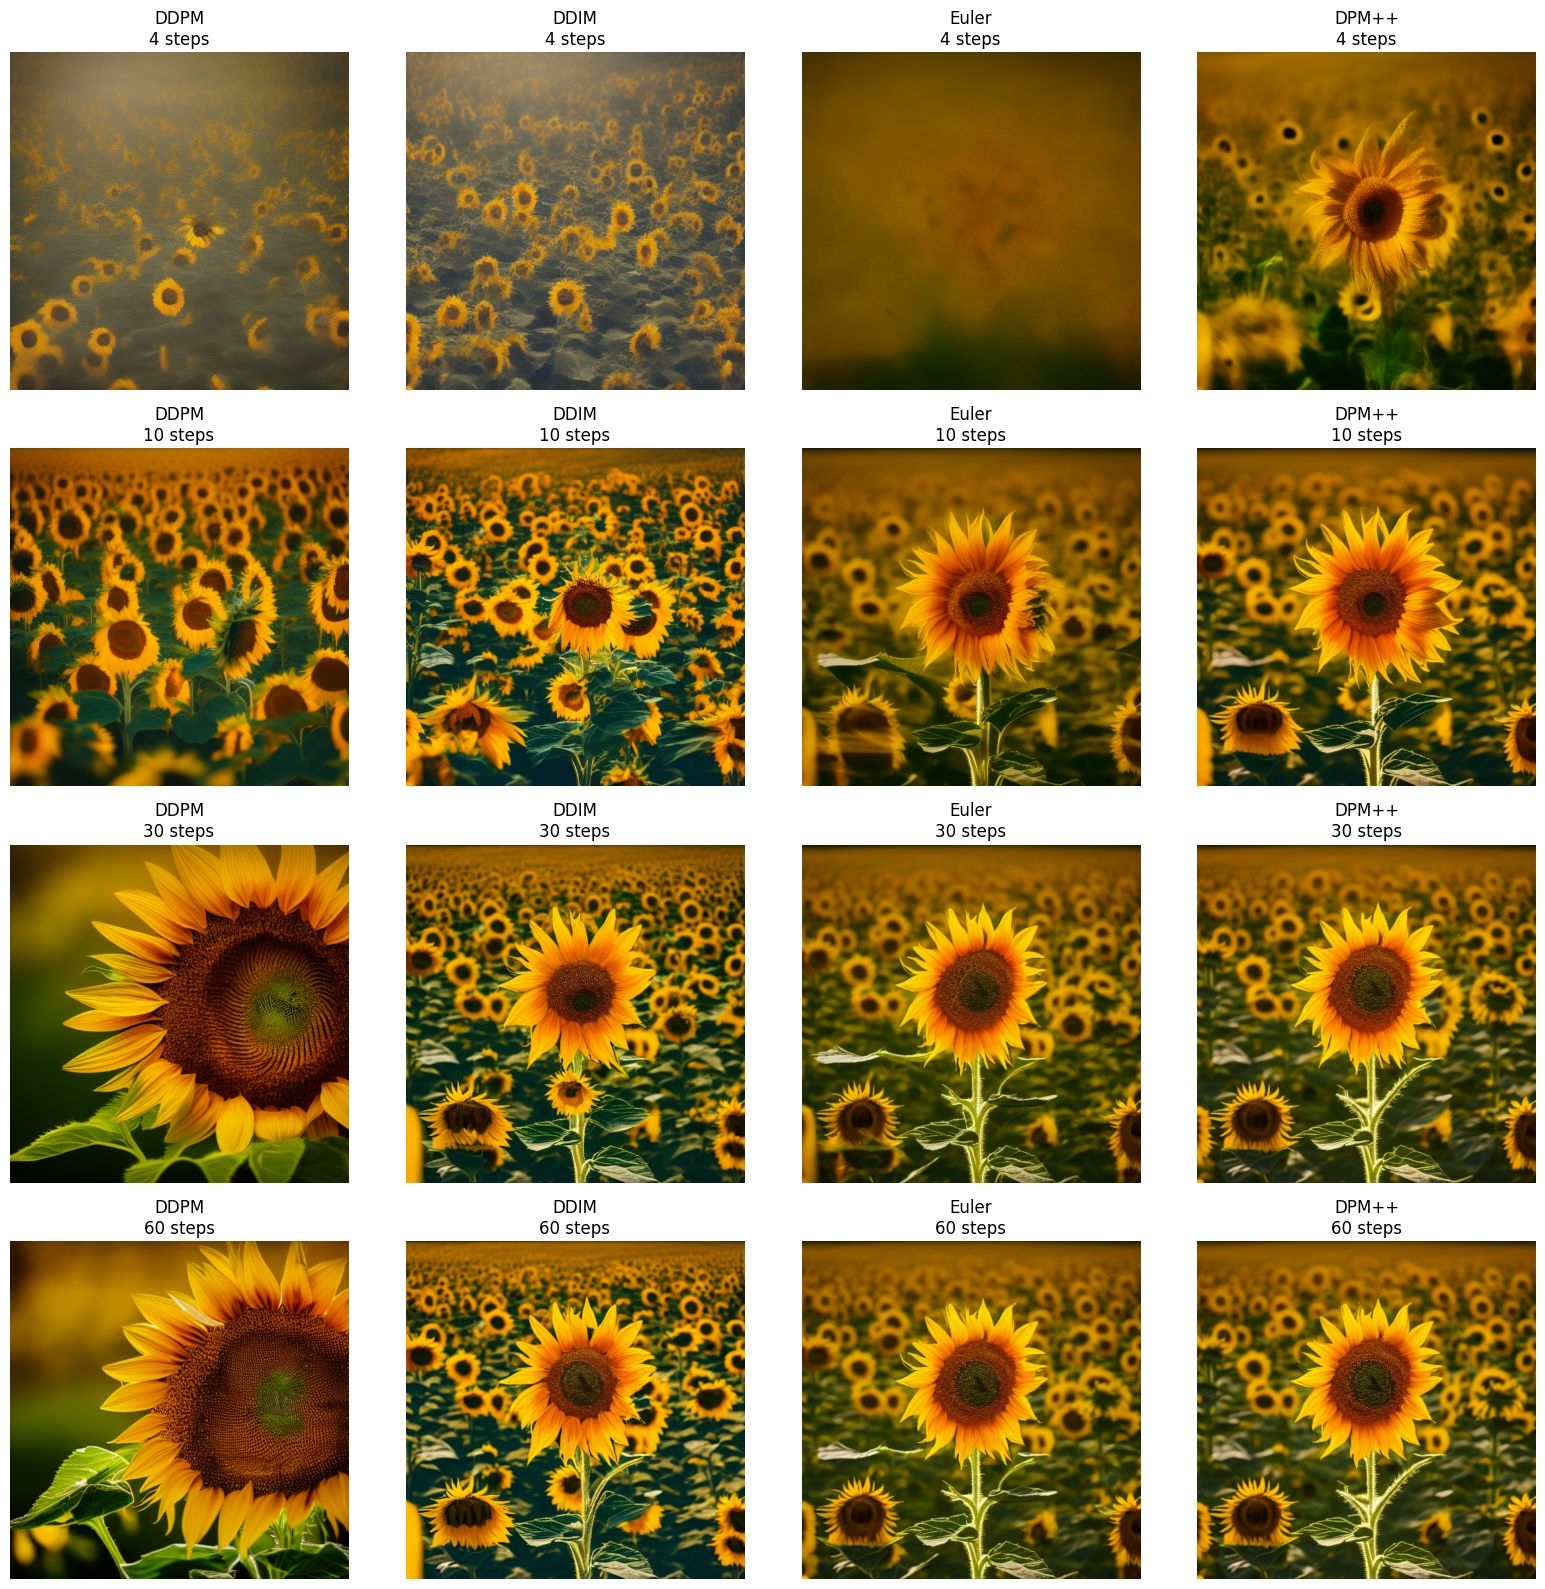

In [18]:
pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()


prompt = "a beautiful close up photo of a vibrant sunflower in a field, highly detailed, cinematic lighting"
seed = 42
guidance = 7.5

step_counts = [4, 10, 30, 60]

samplers_config = {
    "DDPM": DDPMScheduler,
    "DDIM": DDIMScheduler,
    "Euler": EulerDiscreteScheduler,
    "DPM++": DPMSolverMultistepScheduler,
}

def generate(scheduler_class, num_steps, name):
    pipe.scheduler = scheduler_class.from_config(pipe.scheduler.config)

    generator = torch.Generator("cuda").manual_seed(seed)

    start = time.time()

    #create inference pipe for the experiment
    output = pipe(
        prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance,
        generator=generator,
    )
    image = output.images[0]
    elapsed = time.time() - start

    print(f"{name:>8} | {num_steps:3} steps → {elapsed:5.2f}s")

    return image, elapsed

images_dict = {}

for sampler_name, scheduler_class in samplers_config.items():
    for steps in step_counts:
        img, t = generate(scheduler_class, steps, sampler_name)
        images_dict[(sampler_name, steps)] = img

n_steps = len(step_counts)
n_samplers = len(samplers_config)

fig, axs = plt.subplots(
    n_steps, n_samplers,
    figsize=(4 * n_samplers, 4 * n_steps),
    squeeze=False
)

for i, steps in enumerate(step_counts):
    for j, (name, _) in enumerate(samplers_config.items()):
        img = images_dict[(name, steps)]
        axs[i, j].imshow(img)
        axs[i, j].set_title(f"{name}\n{steps} steps", fontsize=12)
        axs[i, j].axis("off")

plt.tight_layout()
plt.show()

In the results we clearly see that DPM++ produced a sensible output the quickest, producing something resembling the last image in just 4 steps. It still looked blurry but it is clearly ahead ahead of the other samplers. DDPM and Euler were the most blurry after 4 steps, having yellow colors or blurry circles. This is because DDPM requires more steps to converge since it makes many small improvements to the image. DDIM while arguably still behind DPM++ produced sunflowers in a field with reasonably defined edges although the quality of the image is still relatively low. It is interesting that after 60 steps DDIM Euler and DPM++ produced similar images meanwhile DDPM produced a single large sunflower rather than a centered sunflower in a field, although all samplers converged to reasonably quality images. DPM++ Converges to a good looking image faster because it uses a different diffusion technique and uses a solver for high order ODEs that solve the diffusion equation more accurately, meaning it can converge quicker than for example Euler which estimates the next step based on the current gradient.




Some limitations of DDIM could be that it fails to fully sample from the training data distribution unlike DDPM which would. Additionally, DDIM is deterministic meanwhile DDPM is not since it must add random noise during inference. Some possible risks of faster and higher quality samplers like DDIM and DPM++ are that harmful or fraudulent content could be created quicker and more convincingly. This is an open problem, of ensuring that models cannot be used to generate potentially harmful content. Some potential solutions involve input filtering and censoring training data to ensure that a model forgets certain concepts and is robust to "model jail breaking".

A possible follow up experiment I would try is using other prompts to better evaluate the samplers performance across a wider variety of data. Additionally, I would try other models. Particularly I'm very interesting in why exactly DDPM produced a very unique image whereas DDIM Euler and DPM++ produced similar results.